# pyanglemania tutorial

`pyanglemania` is a feature-selection method for multi-batch scRNA-seq integration. Conventional
highly-variable-gene (HVG) selection picks genes with high *variance*, which conflates real
biological variation with batch/technical noise. `anglemania` instead looks for genes whose
**pairwise relationships** (the "angle", i.e. correlation, between two genes' expression vectors)
stay stable across batches: it computes a gene-gene correlation matrix per batch, z-scores it
against a permutation-derived null, and keeps genes from pairs whose z-scored correlation is both
large and *consistent* (low standard deviation, high signal-to-noise) across all batches. Genes
selected this way tend to carry batch-invariant biological signal, which makes them a better basis
for downstream integration (Seurat CCA, Harmony, scVI, ...) than plain HVGs, especially when the
biological differences between cell types/states are subtle relative to the batch effect.

This notebook is the Python package's equivalent of an R/Bioconductor vignette: it walks through a
full, runnable example -- simulate batched data, look at it unintegrated, run `pp.anglemania`,
compare the selected genes against HVGs, and integrate both gene sets to see the difference.

See `CLAUDE.md` at the repo root for how this maps onto the original R package's algorithm, and
`tests/` for unit-level checks of each step.

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import harmonypy
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

import pyanglemania as pa

sc.settings.verbosity = 1
rng = np.random.default_rng(0)

## Simulate a multi-batch dataset

`pyanglemania.datasets.example_adata()` (the port of the R package's `sce_example()`) is pure Poisson
noise with no real cell-type structure, which is fine for unit tests but not for showing *why*
gene selection matters for integration. So here we simulate something closer to the R vignette's
`splatter`-based example: a log-linear Poisson model with

- a per-gene baseline log-mean,
- a mild, sparse per-(group, gene) effect for ~15% of genes (the "cell type" signal we want to recover), and
- a per-(batch, gene) effect about twice as large as the biological effect (the batch noise that
  should be "seen through").

Each of 4 batches gets a roughly even mix of 3 groups, so any batch-vs-group structure in a UMAP
later is purely an artifact of how well a method recovers biological vs. technical signal.

In [2]:
n_genes = 1500
n_groups = 3
n_batches = 4
cells_per_batch = 250
de_prob = 0.15        # fraction of genes carrying a group ("cell type") effect
de_facscale = 0.3      # size of that biological effect (log scale)
batch_facscale = 0.15  # size of the batch effect (log scale)

base_log_mean = rng.normal(loc=1.5, scale=1.0, size=n_genes)

de_genes = rng.random(n_genes) < de_prob
group_effect = np.zeros((n_groups, n_genes))
for g in range(n_groups):
    group_effect[g, de_genes] = rng.normal(0, de_facscale, size=de_genes.sum())

batch_effect = rng.normal(0, batch_facscale, size=(n_batches, n_genes))

obs_batch, obs_group, counts_rows = [], [], []
for b in range(n_batches):
    groups_b = rng.integers(0, n_groups, size=cells_per_batch)
    log_mean = base_log_mean[None, :] + group_effect[groups_b] + batch_effect[b][None, :]
    counts_rows.append(rng.poisson(np.exp(log_mean)))
    obs_batch.extend([f"batch{b + 1}"] * cells_per_batch)
    obs_group.extend([f"group{g + 1}" for g in groups_b])

X = np.concatenate(counts_rows, axis=0).astype(np.float32)
obs = pd.DataFrame(
    {"batch": obs_batch, "group": obs_group},
    index=[f"cell{i + 1}" for i in range(X.shape[0])],
)
var = pd.DataFrame(index=[f"gene{i + 1}" for i in range(n_genes)])
adata = ad.AnnData(X=X, obs=obs, var=var)
adata.layers["counts"] = adata.X.copy()  # anglemania wants raw counts
adata

AnnData object with n_obs × n_vars = 1000 × 1500
    obs: 'batch', 'group'
    layers: 'counts'

In [3]:
adata.obs.groupby(["batch", "group"]).size().unstack()

group,group1,group2,group3
batch,,,
batch1,88,84,78
batch2,88,91,71
batch3,69,78,103
batch4,85,72,93


## Unintegrated workflow

Standard scanpy normalization, log1p, HVG-based PCA, and UMAP -- no batch correction. If the batch
effect is doing what we designed it to do, the UMAP should cluster by `batch` at least as strongly
as by `group`.

/home/akollot/miniforge3/envs/pyanglemania/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


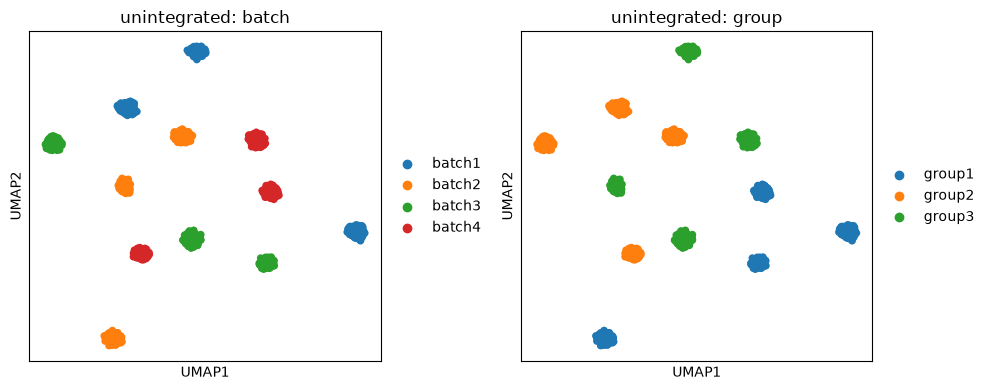

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata_unintegrated = adata.copy()
sc.pp.highly_variable_genes(adata_unintegrated, n_top_genes=500)
sc.pp.pca(adata_unintegrated, mask_var="highly_variable")
sc.pp.neighbors(adata_unintegrated)
sc.tl.umap(adata_unintegrated)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sc.pl.umap(adata_unintegrated, color="batch", ax=axes[0], show=False, title="unintegrated: batch")
sc.pl.umap(adata_unintegrated, color="group", ax=axes[1], show=False, title="unintegrated: group")
fig.tight_layout()

As expected, cells separate by `batch` rather than by the biological `group` label -- exactly the
failure mode anglemania and HVG-based integration are both trying to fix.

## Run `pp.anglemania`

The key arguments:

- `batch_key`: the `adata.obs` column that defines batches -- gene-gene angles are computed
  separately per batch and only genes whose relationships are *consistent across batches* survive.
- `layer`: anglemania expects raw counts (it does its own CP10K+log1p normalization internally per
  batch); we kept those in `adata.layers["counts"]` above since `adata.X` is now normalized/logged.
- `max_n_genes`: cap on how many genes to keep, ranked by a weighted combination of |mean z-score|
  and z-score standard deviation across batches (see `score_weights`).

This mirrors the R package's `anglemania()` call almost one-to-one; see `CLAUDE.md` for the full
parameter list and where each step lives in `src/pyanglemania/preprocessing/`.

In [5]:
pa.pp.anglemania(
    adata,
    batch_key="batch",
    layer="counts",
    max_n_genes=500,
)

Preparing input...
Filtering each batch to at least 1 cells per gene...
Using the intersection of filtered genes from all batches...
Number of genes in intersected set: 1500
Computing angles and transforming to z-scores...


Computing statistics...
Pre-filtering features...


Extracting filtered features...


Selected 500 genes for integration.


AnnData object with n_obs × n_vars = 1000 × 1500
    obs: 'batch', 'group', 'anglemania_batch'
    var: 'anglemania_genes'
    uns: 'log1p', 'anglemania'
    layers: 'counts'

### Inspect the results

Results land in `adata.var["anglemania_genes"]` (boolean mask) and `adata.uns["anglemania"]`
(params, the intersected gene universe, and the ranked gene-pair statistics table).

In [6]:
print(adata.var["anglemania_genes"].sum(), "genes selected")
adata.uns["anglemania"]["prefiltered_df"].head()

500 genes selected


,geneA,geneB,mean_zscore,sd_zscore,sn_zscore,rank
0,gene637,gene1399,-10.411180,0.081751,127.352556,1.0
1,gene373,gene434,8.200725,0.068035,120.537152,2.0
2,gene293,gene1435,8.241684,0.071865,114.682643,3.0
3,gene134,gene150,9.635624,0.114235,84.349145,4.0
4,gene158,gene436,-6.157698,0.081660,75.406099,5.0


## Compare with `highly_variable_genes`

For a fair comparison we ask scanpy for the same number of HVGs anglemania selected, then check how
much the two gene sets actually agree.

In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes=int(adata.var["anglemania_genes"].sum()))

angl_genes = set(adata.var_names[adata.var["anglemania_genes"]])
hvg_genes = set(adata.var_names[adata.var["highly_variable"]])
print(f"{len(angl_genes & hvg_genes)} of {len(angl_genes)} anglemania genes are also HVGs")

246 of 500 anglemania genes are also HVGs


Substantial but partial overlap is expected: both methods are looking for informative genes, but
anglemania is explicitly selecting for batch-*invariance*, which HVG variance ranking doesn't
consider at all.

## Integrate both gene sets and compare

We run the same workflow -- scale, PCA, [Harmony](https://github.com/slowkow/harmonypy) batch
correction, neighbors, UMAP -- on each gene set, then look at both the UMAP and a quantitative
proxy: average silhouette width (ASW) computed on the Harmony-corrected PCA embedding, by `group`
(higher is better -- biological signal preserved) and by `batch` (lower is better -- well mixed).

(We call `harmonypy` directly rather than through `scanpy.external.pp.harmony_integrate` here,
since the installed `harmonypy` returns `Z_corr` already as `cells x PCs` and scanpy's wrapper -- written
against an older convention -- transposes it into the wrong shape.)

In [8]:
def run_harmony(pca, batch):
    ho = harmonypy.run_harmony(pca, pd.DataFrame({"batch": batch.to_numpy()}), ["batch"])
    z = np.asarray(ho.Z_corr)
    return z if z.shape[0] == pca.shape[0] else z.T


def integrate(adata_full, gene_set):
    sub = adata_full[:, adata_full.var_names.isin(gene_set)].copy()
    sc.pp.scale(sub, max_value=10)
    sc.pp.pca(sub, n_comps=30)
    sub.obsm["X_pca_harmony"] = run_harmony(sub.obsm["X_pca"], sub.obs["batch"])
    sc.pp.neighbors(sub, use_rep="X_pca_harmony")
    sc.tl.umap(sub)
    return sub


sub_angl = integrate(adata, angl_genes)
sub_hvg = integrate(adata, hvg_genes)

2026-06-22 08:17:01,779 - harmonypy - INFO - Running Harmony (PyTorch on cpu)


2026-06-22 08:17:01,780 - harmonypy - INFO -   Parameters:


2026-06-22 08:17:01,780 - harmonypy - INFO -     max_iter_harmony: 10


2026-06-22 08:17:01,780 - harmonypy - INFO -     max_iter_kmeans: 20


2026-06-22 08:17:01,781 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-06-22 08:17:04,970 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-06-22 08:17:04,999 - harmonypy - INFO - KMeans initialization complete.


2026-06-22 08:17:05,002 - harmonypy - INFO - Iteration 1 of 10


2026-06-22 08:17:05,100 - harmonypy - INFO - Iteration 2 of 10


2026-06-22 08:17:05,156 - harmonypy - INFO - Converged after 2 iterations


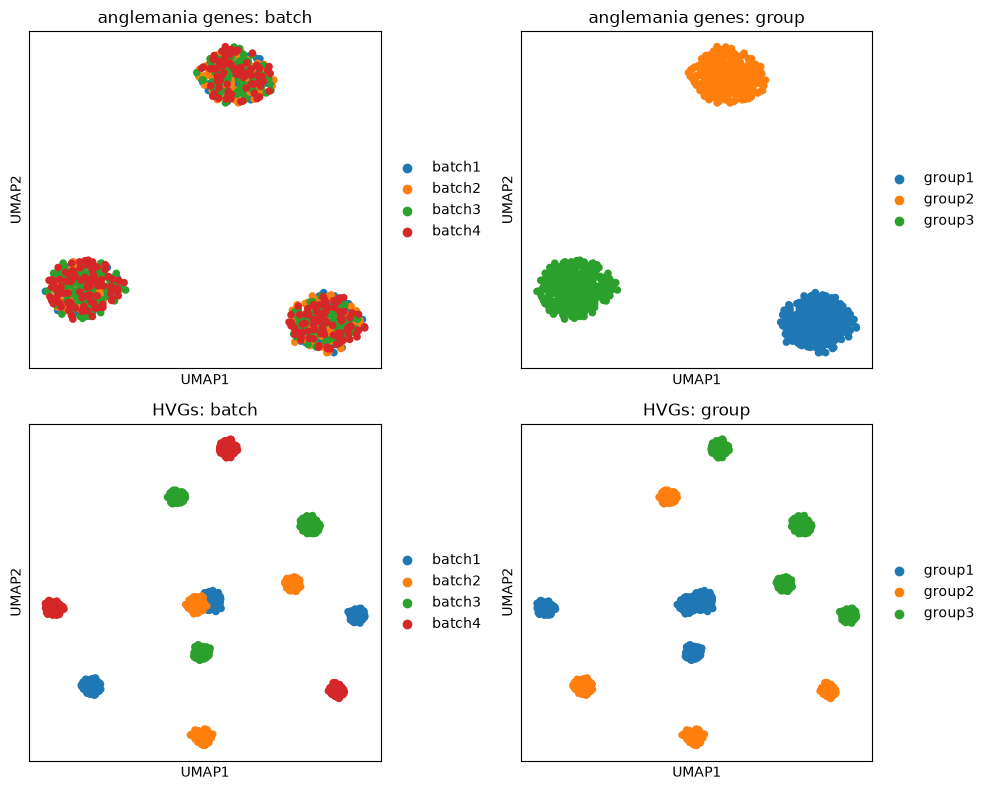

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sc.pl.umap(sub_angl, color="batch", ax=axes[0, 0], show=False, title="anglemania genes: batch")
sc.pl.umap(sub_angl, color="group", ax=axes[0, 1], show=False, title="anglemania genes: group")
sc.pl.umap(sub_hvg, color="batch", ax=axes[1, 0], show=False, title="HVGs: batch")
sc.pl.umap(sub_hvg, color="group", ax=axes[1, 1], show=False, title="HVGs: group")
fig.tight_layout()

In [10]:
rows = [
    (
        "unintegrated (HVG, no correction)",
        silhouette_score(adata_unintegrated.obsm["X_pca"], adata_unintegrated.obs["group"]),
        silhouette_score(adata_unintegrated.obsm["X_pca"], adata_unintegrated.obs["batch"]),
    ),
    (
        "Harmony + anglemania genes",
        silhouette_score(sub_angl.obsm["X_pca_harmony"], sub_angl.obs["group"]),
        silhouette_score(sub_angl.obsm["X_pca_harmony"], sub_angl.obs["batch"]),
    ),
    (
        "Harmony + HVGs",
        silhouette_score(sub_hvg.obsm["X_pca_harmony"], sub_hvg.obs["group"]),
        silhouette_score(sub_hvg.obsm["X_pca_harmony"], sub_hvg.obs["batch"]),
    ),
]
pd.DataFrame(rows, columns=["embedding", "ASW group (higher better)", "ASW batch (lower better)"])

,embedding,ASW group (higher better),ASW batch (lower better)
0,"unintegrated (HVG, no correction)",0.166257,0.138561
1,Harmony + anglemania genes,0.376582,-0.012914
2,Harmony + HVGs,0.239554,0.150155


On this simulated dataset, Harmony with anglemania-selected genes recovers the three `group`
clusters cleanly with batches mixed inside each one, while the same correction on HVGs still leaves
visible batch-driven sub-structure within each group -- consistent with the higher group ASW / lower
batch ASW in the table above. This is a toy, seeded simulation meant to illustrate the *mechanism*
(picking genes for batch-invariant relationships rather than raw variance), not a benchmark result.

## Where to go from here

- Every step above (`factorise`, the streaming `StreamingZscoreStats` cross-batch reduction,
  `prefilter_gene_pairs`/`rank_gene_pairs`) is unit-tested in `tests/`; read those for precise,
  minimal examples of each piece.
- `adata.uns["anglemania"]["anglemania_genes"]` is a plain list of gene names -- pass it as
  `features`/`var_names_subset` to whatever integration method you use downstream (Harmony above,
  or e.g. `scvi.model.SCVI.setup_anndata(adata[:, anglemania_genes], batch_key="batch")`).
- The same code runs unmodified on a GPU-resident `AnnData` (e.g. after
  `rapids_singlecell.get.anndata_to_GPU(adata)`) since every numeric step dispatches through
  `pyanglemania._utils.get_array_module` rather than importing numpy directly -- see `CLAUDE.md`
  for the caveat that this path is implemented but not yet execution-tested on real GPU hardware.